In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['text.usetex'] = True

In [2]:
df = pd.read_csv('Ratio2.csv')
df.head()

,Lb/ry,h/tw,B/2t,h/B,tf/tw,E/Fy,Mp/Mcr,Mn/Mp (Formula),Mn/Mp (FEM)
0,45.845272,41.0,41.0,41.0,1.718447,208.279468,0.565131,0.843663,0.960437
1,54.441261,41.0,41.0,41.0,1.718447,208.279468,0.777663,0.760744,0.876255
2,65.902579,41.0,41.0,41.0,1.718447,208.279468,1.098379,0.647926,0.754739
3,74.498567,41.0,41.0,41.0,1.718447,208.279468,1.361943,0.570788,0.616700
4,85.959885,41.0,41.0,41.0,1.718447,208.279468,1.737479,0.483207,0.423960


0.06592044583181819
0.006898473819338421
0.827627726545856


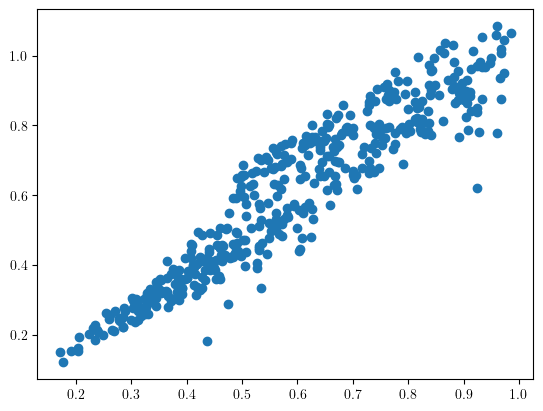

In [3]:
mae_formula = mean_absolute_error(df['Mn/Mp (Formula)'], df['Mn/Mp (FEM)'])
mse_formula = mean_squared_error(df['Mn/Mp (Formula)'], df['Mn/Mp (FEM)'])
r2_formula = r2_score(df['Mn/Mp (Formula)'], df['Mn/Mp (FEM)'])
print(mae_formula)
print(mse_formula)
print(r2_formula)
plt.scatter(df['Mn/Mp (Formula)'], df['Mn/Mp (FEM)'])
plt.show()

In [4]:
df = df.drop(columns='Mn/Mp (Formula)')
df = df.rename(columns={'Mn/Mp (FEM)' : 'Mn/Mp'})
df.head()

,Lb/ry,h/tw,B/2t,h/B,tf/tw,E/Fy,Mp/Mcr,Mn/Mp
0,45.845272,41.0,41.0,41.0,1.718447,208.279468,0.565131,0.960437
1,54.441261,41.0,41.0,41.0,1.718447,208.279468,0.777663,0.876255
2,65.902579,41.0,41.0,41.0,1.718447,208.279468,1.098379,0.754739
3,74.498567,41.0,41.0,41.0,1.718447,208.279468,1.361943,0.616700
4,85.959885,41.0,41.0,41.0,1.718447,208.279468,1.737479,0.423960


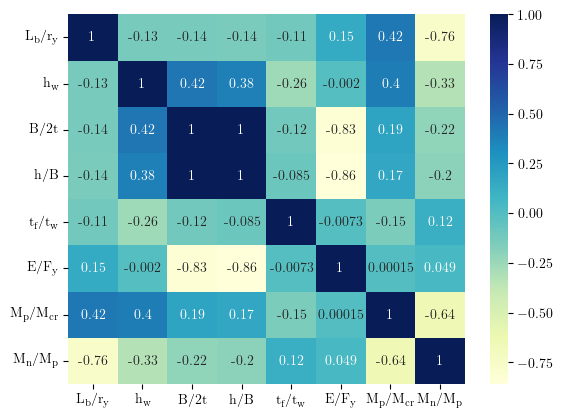

In [5]:
tempdf = df.rename(columns=
    {"Lb/ry": r"L\textsubscript{b}/r\textsubscript{y}",
     "h/tw" :r"h\textsubscript{w}",
     "tf/tw" : r"t\textsubscript{f}/t\textsubscript{w}",
     "E/Fy" : r"E/F\textsubscript{y}",
     "Mp/Mcr" : r"M\textsubscript{p}/M\textsubscript{cr}",
     "Mn/Mp" : r"M\textsubscript{n}/M\textsubscript{p}"
    }, errors="raise")
sns.heatmap(tempdf.corr(numeric_only=True), cmap="YlGnBu", annot=True)
plt.savefig(f'crosscorrelation.png', dpi=640, bbox_inches='tight')

In [6]:
df_stats = df.describe().transpose()
df_stats = df_stats[['mean', 'std']]
df_stats['variance'] = df_stats['std'] ** 2
df_stats

,mean,std,variance
Lb/ry,97.486874,37.039161,1371.899416
h/tw,34.935256,14.073340,198.058890
B/2t,20.302237,17.728369,314.295050
h/B,18.406437,19.309198,372.845135
tf/tw,1.653682,0.116313,0.013529
E/Fy,249.029618,40.796536,1664.357331
Mp/Mcr,1.787570,1.034825,1.070864
Mn/Mp,0.596575,0.235798,0.055601


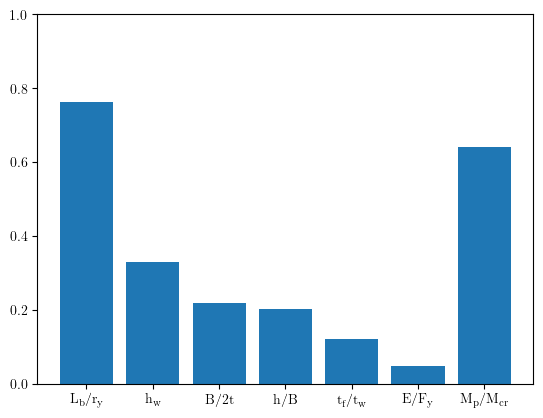

In [7]:
C = tempdf.corr(numeric_only=True)[r'M\textsubscript{n}/M\textsubscript{p}'][:-1]
plt.bar(C.index, np.abs(C.values))
plt.ylim([0, 1])

plt.savefig(f'correlation-with-Mn-Mp.png', dpi=640, bbox_inches='tight')

In [8]:
X_full = df[['Lb/ry', 'h/tw', 'B/2t', 'h/B', 'tf/tw', 'E/Fy', 'Mp/Mcr']]
y_full = df['Mn/Mp']

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.2, random_state=1337)

In [10]:
def evaluate_pipeline(pipeline, threshold=0.2):
    pipeline_train_prd = pipeline.predict(X_train)
    pipeline_train_outliers = np.abs(pipeline_train_prd - y_train) > threshold
    mod_pipeline_train_prd = pipeline_train_prd[~ pipeline_train_outliers]
    mod_y_train = y_train[~ pipeline_train_outliers]
    pipeline_train_mse = mean_squared_error(mod_pipeline_train_prd, mod_y_train)
    pipeline_train_mae = mean_absolute_error(mod_pipeline_train_prd, mod_y_train)
    pipeline_train_r2_score = r2_score(mod_pipeline_train_prd, mod_y_train)
    
    pipeline_test_prd = pipeline.predict(X_test)
    pipeline_test_outliers = np.abs(pipeline_test_prd - y_test) > threshold
    mod_pipeline_test_prd = pipeline_test_prd[~ pipeline_test_outliers]
    mod_y_test = y_test[~ pipeline_test_outliers]
    pipeline_test_mse = mean_squared_error(mod_pipeline_test_prd, mod_y_test)
    pipeline_test_mae = mean_absolute_error(mod_pipeline_test_prd, mod_y_test)
    pipeline_test_r2_score = r2_score(mod_pipeline_test_prd, mod_y_test)
    
    pipeline_full_prd = pipeline.predict(X_full)
    pipeline_full_outliers = np.abs(pipeline_full_prd - y_full) > threshold
    mod_pipeline_full_prd = pipeline_full_prd[~ pipeline_full_outliers]
    mod_y_full = y_full[~ pipeline_full_outliers]
    pipeline_full_mse = mean_squared_error(mod_pipeline_full_prd, mod_y_full)
    pipeline_full_mae = mean_absolute_error(mod_pipeline_full_prd, mod_y_full)
    pipeline_full_r2_score = r2_score(mod_pipeline_full_prd, mod_y_full)
    
    metrics = {
        'y_train': mod_y_train,
        'y_test' : mod_y_test,
        'train_mse': pipeline_train_mse,
        'train_mae': pipeline_train_mae,
        'train_r2': pipeline_train_r2_score,
        'test_mse': pipeline_test_mse,
        'test_mae': pipeline_test_mae,
        'test_r2': pipeline_test_r2_score,
        'full_mse': pipeline_full_mse,
        'full_mae': pipeline_full_mae,
        'full_r2': pipeline_full_r2_score,
        'train_predictions': mod_pipeline_train_prd,
        'test_predictions': mod_pipeline_test_prd
    }

    return metrics

def plot_accuracy(pipeline_metrics, title):
    print(title)
    print(pipeline_metrics)
    y_train = pipeline_metrics['y_train']
    y_test = pipeline_metrics['y_test']
    
    pipeline_train_prd = pipeline_metrics['train_predictions']
    pipeline_test_prd = pipeline_metrics['test_predictions']
    pipeline_train_r2_score = pipeline_metrics['train_r2']
    pipeline_test_r2_score = pipeline_metrics['test_r2']
    pipeline_full_r2_score = pipeline_metrics['full_r2']
    
    
    fig_train, axes = plt.subplots(figsize=(4, 4))
    axes.plot([0, 1], [0, 1])
    axes.text(0.1, 0.7, f'$R^2={pipeline_train_r2_score:.5f}$')
    axes.plot(y_train, pipeline_train_prd, 'bo', alpha=0.5, markeredgewidth=0.1, label='Train data');
    axes.set_xlabel('Actual Value')
    axes.set_ylabel('Predicted Value')
    axes.legend()
    fig_train.savefig(f'{title}/{title}-train.png', dpi=640, bbox_inches='tight')

    fig_test, axes = plt.subplots(figsize=(4, 4))
    axes.plot([0, 1], [0, 1])
    axes.text(0.1, 0.7, f'$R^2={pipeline_test_r2_score:.5f}$')
    axes.plot(y_test, pipeline_test_prd, 'ro', alpha=0.5, markeredgewidth=0.1, label='Test data');
    axes.set_xlabel('Actual Value')
    axes.set_ylabel('Predicted Value')
    axes.legend()
    fig_test.savefig(f'{title}/{title}-test.png', dpi=640, bbox_inches='tight')

    fig_full, axes = plt.subplots(figsize=(4, 4))
    axes.plot([0, 1], [0, 1])
    axes.text(0.1, 0.7, f'$R^2={pipeline_full_r2_score:.5f}$')
    axes.plot(y_train, pipeline_train_prd, 'bo', alpha=0.5, markeredgewidth=0.1, label='Train data');
    axes.plot(y_test, pipeline_test_prd, 'ro', alpha=0.5, markeredgewidth=0.1, label='Test data');
    axes.set_xlabel('Actual Value')
    axes.set_ylabel('Predicted Value')
    axes.legend()
    fig_full.savefig(f'{title}/{title}-full.png', dpi=640, bbox_inches='tight')

def plot_cross_validation(cv_result, titlename):
    mean_mse = cv_result['mean_test_score']
    criterions = cv_result['params'][0].keys()
    
    params_df = pd.DataFrame(cv_result['params'].tolist())
    heatmap_data = params_df.copy()
    heatmap_data['mean_r2'] = mean_mse
    if all(mean_mse < 0):
        heatmap_data['mean_r2'] = -mean_mse

    for col in params_df.columns:
        df = heatmap_data.groupby(col)['mean_r2'].min()
        metrics = df.keys().tolist()
        values = df.values.tolist()
        
        angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()

        values = np.concatenate((values, [values[0]]))  # Close the loop
        angles += angles[:1]
        
        fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
        # print(np.max(values) * 1.1)
        # ax.set_rlim(np.max(values) * 1.1)
        ax.margins(0.1)
        ax.scatter(angles, values)
        ax.plot(angles, values, '--')
        ax.fill(angles, values, alpha=0.25)
        
        # Set axis labels
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(metrics)

        plt.savefig(f'{titlename}/{titlename}-hyperparam-{col}.png', dpi=640, bbox_inches='tight')

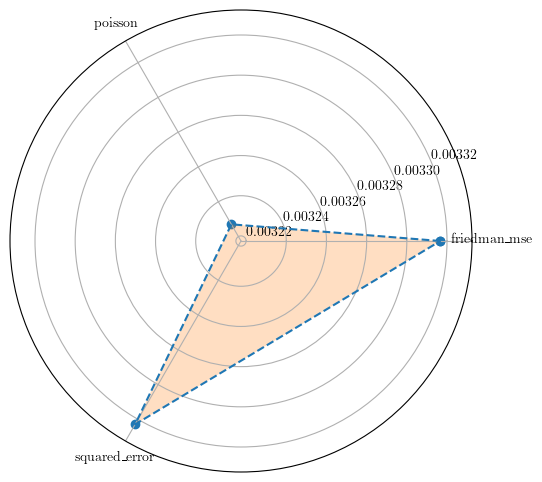

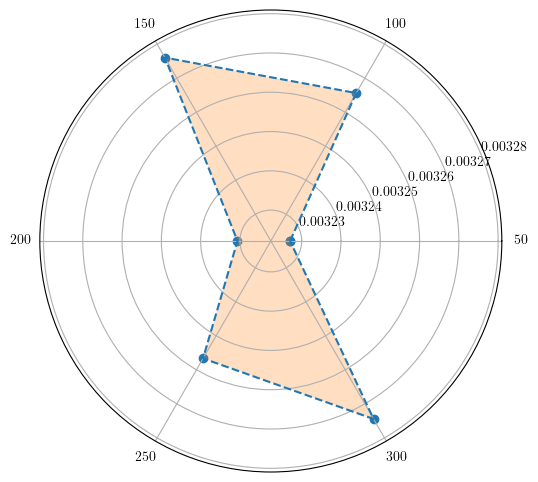

In [11]:
rf_params = {
    'criterion' : ['squared_error', 'friedman_mse', 'poisson'],
    'n_estimators' : [50, 100, 150, 200, 250, 300],
}

rf_cv = GridSearchCV(RandomForestRegressor(random_state=42), rf_params, scoring='neg_mean_squared_error')
rf_cv.fit(X_train, y_train)
rf_best = rf_cv.best_estimator_
rf_metrics = evaluate_pipeline(rf_best)

rf_cv_result = pd.DataFrame(rf_cv.cv_results_)
plot_cross_validation(rf_cv_result, 'random-forest')

random-forest
{'y_train': 204    0.678858
128    0.399096
315    0.479181
97     0.734070
318    0.476939
         ...   
167    0.650541
232    0.494174
348    0.840543
189    0.486737
151    0.776924
Name: Mn/Mp, Length: 352, dtype: float64, 'y_test': 398    0.865497
295    0.343300
200    0.295856
214    0.492424
330    0.818659
         ...   
304    0.767434
184    0.625606
269    0.402378
40     0.355125
33     0.268164
Name: Mn/Mp, Length: 86, dtype: float64, 'train_mse': 0.00044585958435118517, 'train_mae': 0.01617993156130683, 'train_r2': 0.9916811599750383, 'test_mse': 0.0025617417590692243, 'test_mae': 0.03927872218488375, 'test_r2': 0.9484637031589226, 'full_mse': 0.0008613067693414851, 'full_mae': 0.0207153105421918, 'full_r2': 0.9837057192084169, 'train_predictions': array([0.65479525, 0.41515377, 0.51437759, 0.74903842, 0.47927837,
       0.71529616, 0.7854816 , 0.52853736, 0.70014612, 0.67974108,
       0.87265834, 0.29999631, 0.80989244, 0.83985485, 0.76000577,
       

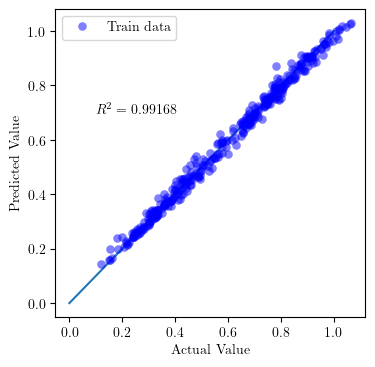

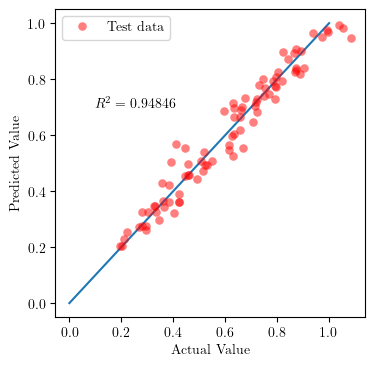

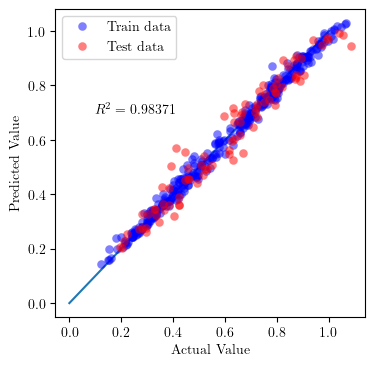

In [12]:
rf_metrics = evaluate_pipeline(rf_best)
plot_accuracy(rf_metrics, 'random-forest')

In [13]:
gb_params = {
    'n_estimators' : [200, 300, 500, 1000],
    'learning_rate' : [0.01, 0.02, 0.05, 0.1],
    'max_depth' : [2, 3, 4],
}

gb_cv = GridSearchCV(GradientBoostingRegressor(random_state=42, subsample=0.7), gb_params, scoring='neg_mean_squared_error')
gb_cv.fit(X_train, y_train)
gb_best = gb_cv.best_estimator_

print(gb_cv.best_params_)

{'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 1000}


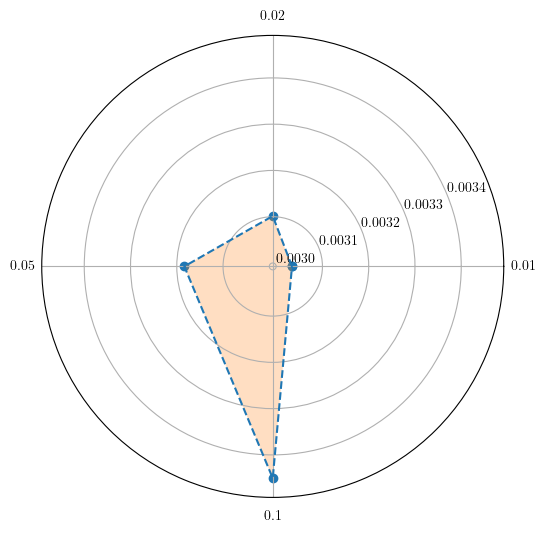

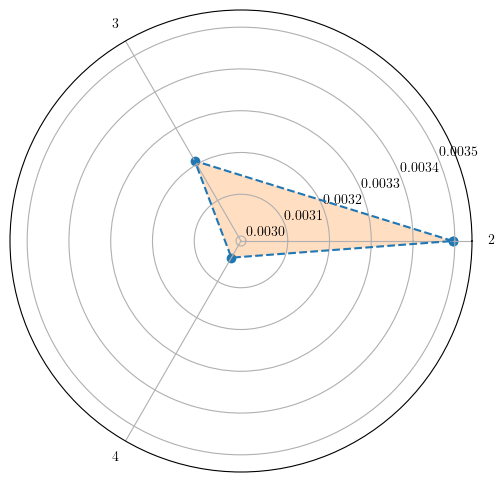

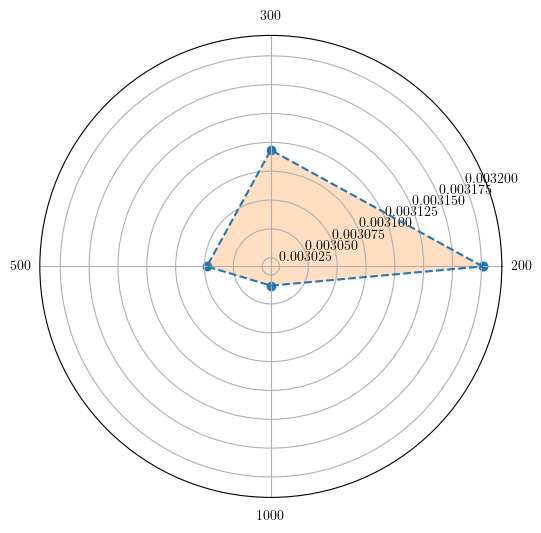

In [14]:
gb_cv_result = pd.DataFrame(gb_cv.cv_results_)
plot_cross_validation(gb_cv_result, 'gradient-boosting')

gradient-boosting
{'y_train': 204    0.678858
128    0.399096
315    0.479181
97     0.734070
318    0.476939
         ...   
167    0.650541
232    0.494174
348    0.840543
189    0.486737
151    0.776924
Name: Mn/Mp, Length: 352, dtype: float64, 'y_test': 398    0.865497
295    0.343300
200    0.295856
214    0.492424
330    0.818659
         ...   
304    0.767434
184    0.625606
269    0.402378
40     0.355125
33     0.268164
Name: Mn/Mp, Length: 88, dtype: float64, 'train_mse': 0.0003360366141261829, 'train_mae': 0.014762661367159046, 'train_r2': 0.993882507621777, 'test_mse': 0.00398778875153338, 'test_mae': 0.04158814044002021, 'test_r2': 0.922580231484491, 'full_mse': 0.0010663870416076223, 'full_mae': 0.020127757181731275, 'full_r2': 0.980359674024184, 'train_predictions': array([0.66590383, 0.41138393, 0.49341275, 0.7654627 , 0.47140838,
       0.71198733, 0.79649309, 0.51544038, 0.7083755 , 0.66035432,
       0.80862549, 0.30627596, 0.82183919, 0.8315508 , 0.76034649,
      

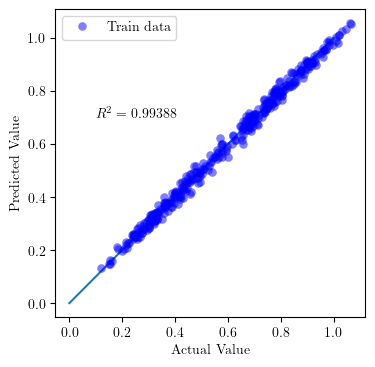

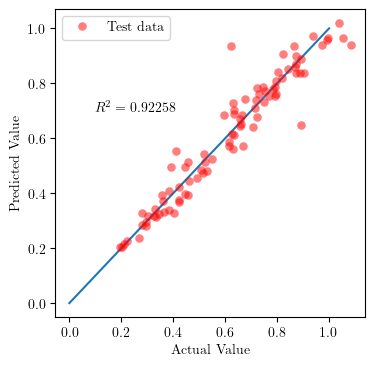

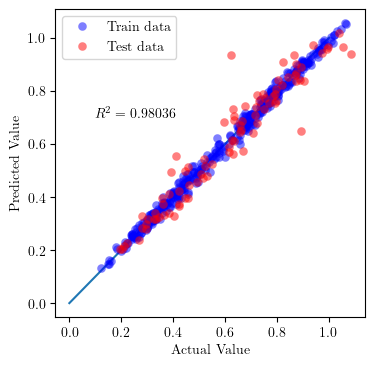

In [15]:
gb_metrics = evaluate_pipeline(gb_best, 1000000000)
plot_accuracy(gb_metrics, 'gradient-boosting')

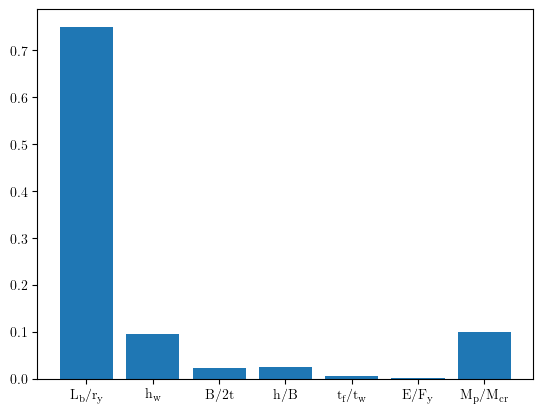

In [16]:
feature_importance = gb_best.feature_importances_
plt.bar(tempdf.columns[:7], feature_importance)
plt.savefig('gradient-boosting/feature-imp.png', dpi=640, bbox_inches='tight')

In [17]:
from sklearn.svm import LinearSVR, SVR
from scipy.stats import loguniform, uniform
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

kernels = ['linear', 'rbf', 'poly']
svr_params = {
    'svr__C': loguniform(1e-1, 1e2),
    'svr__epsilon': uniform(0.01, 0.1)
}

svr_metrics = dict()

for kernel in ['linear', 'rbf', 'poly']:
    if kernel == 'linear':
        base_model = SVR(kernel=kernel)
        base_params = svr_params
    else:
        base_model = SVR(kernel=kernel)
        base_params = {**svr_params, 'svr__gamma': loguniform(1e-3, 1e3)}

    svr_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svr', base_model)
    ])

    svr_cv = RandomizedSearchCV(svr_pipeline, base_params, n_iter=10, random_state=100, n_jobs=-1, scoring='neg_mean_squared_error')
    svr_cv.fit(X_train, y_train)
    
    svr_best = svr_cv.best_estimator_
    svr_cv_result = pd.DataFrame(svr_cv.cv_results_)
    print(svr_cv.best_params_)

    svr_metrics[kernel] = evaluate_pipeline(svr_best)

{'svr__C': 1.8773825301295222, 'svr__epsilon': 0.09447761323199037}
{'svr__C': 86.27229557752123, 'svr__epsilon': 0.09116831490893233, 'svr__gamma': 0.01075588317270133}
{'svr__C': 4.2679058013626765, 'svr__epsilon': 0.037836938509379615, 'svr__gamma': 0.3524565164435525}


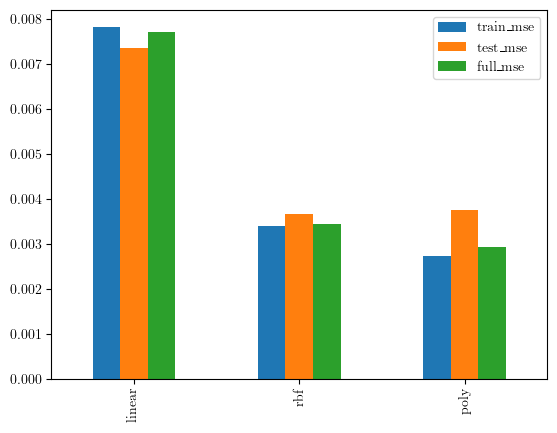

In [18]:
pd.DataFrame(svr_metrics).filter(regex='_mse', axis=0).transpose().plot.bar()
plt.savefig('svr/svr-kernel-mse.png', dpi=640, bbox_inches='tight')

SVR-linear
{'y_train': 204    0.678858
128    0.399096
315    0.479181
97     0.734070
21     0.702549
         ...   
167    0.650541
232    0.494174
348    0.840543
189    0.486737
151    0.776924
Name: Mn/Mp, Length: 345, dtype: float64, 'y_test': 398    0.865497
295    0.343300
200    0.295856
214    0.492424
330    0.818659
         ...   
304    0.767434
184    0.625606
269    0.402378
40     0.355125
33     0.268164
Name: Mn/Mp, Length: 84, dtype: float64, 'train_mse': 0.007807453143685728, 'train_mae': 0.07288913320875907, 'train_r2': 0.8276390498298906, 'test_mse': 0.007341026607851118, 'test_mae': 0.07276484584193206, 'test_r2': 0.820618037910525, 'full_mse': 0.007716124870934895, 'full_mae': 0.07286479722084889, 'full_r2': 0.826406373056761, 'train_predictions': array([ 0.63757205,  0.5915176 ,  0.33802377,  0.77602932,  0.69319525,
        0.87384876,  0.61880207,  0.66092399,  0.63734732,  0.96126639,
        0.28285641,  0.79224014,  0.86115112,  0.71730834,  0.75566332,


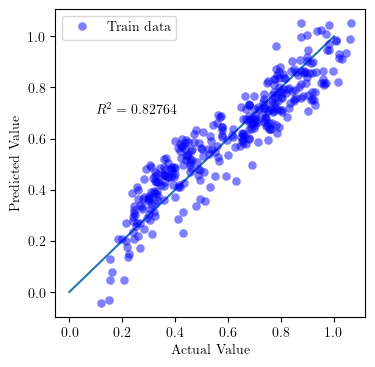

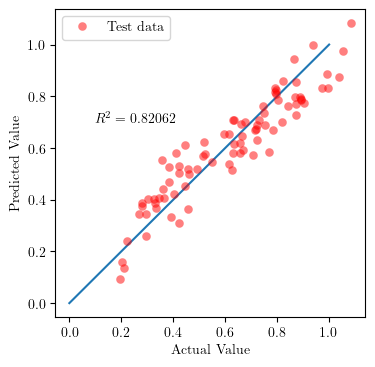

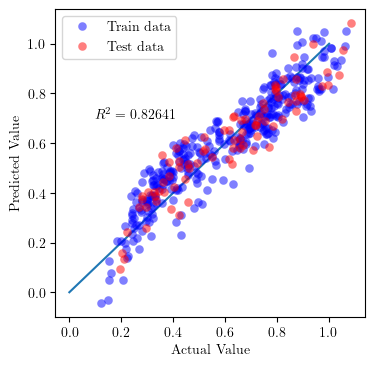

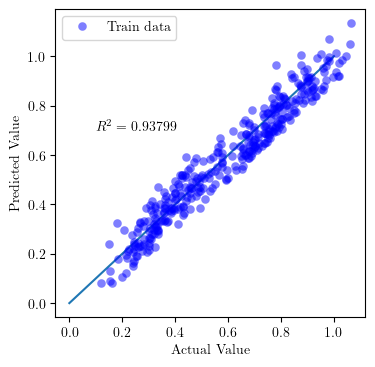

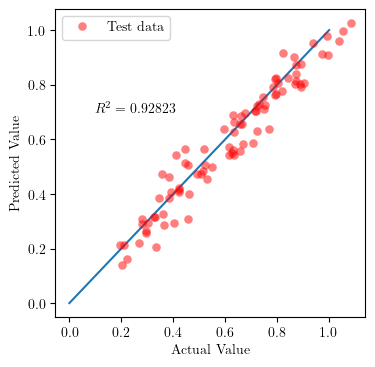

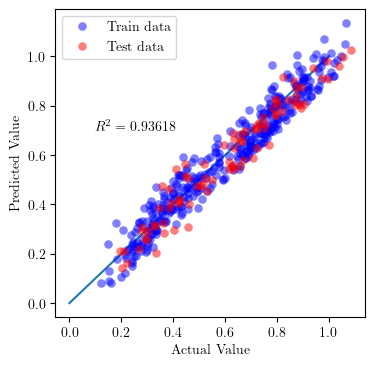

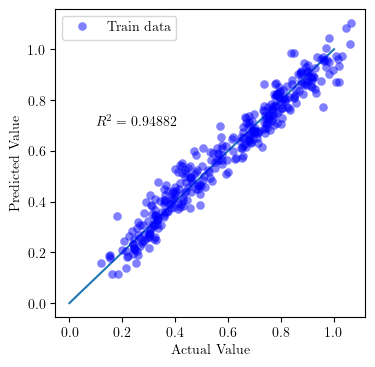

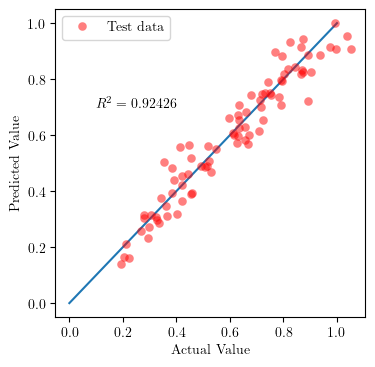

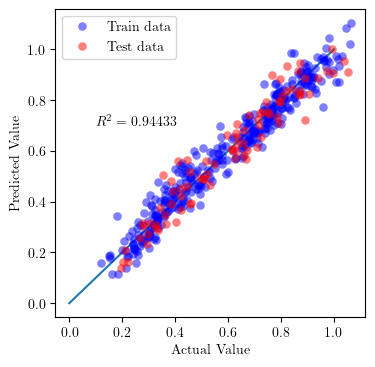

In [19]:
for kernel in kernels:
    plot_accuracy(svr_metrics[kernel], f'SVR-{kernel}')

In [20]:
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

nn_params = {
    'mlp__hidden_layer_sizes' : [(20, 20, 20, 20, 20, 20, 20)],
    'mlp__activation' : ['relu'],
    'mlp__solver': ['lbfgs']
}

nn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(random_state=100, early_stopping=True, max_iter=1000))
])

nn_cv = GridSearchCV(nn_pipeline, nn_params, scoring='neg_mean_squared_error')
nn_cv.fit(X_train, y_train)

nn_best = nn_cv.best_estimator_
nn_cv_result = pd.DataFrame(nn_cv.cv_results_)

# plt.subplot(2, 1, 1)
# plt.semilogy(nn_best['mlp'].loss_curve_)
# plt.subplot(2, 1, 2)
# plt.plot(nn_best['mlp'].validation_scores_)
# plt.savefig('MLP/mlp.png', dpi=640, bbox_inches='tight')

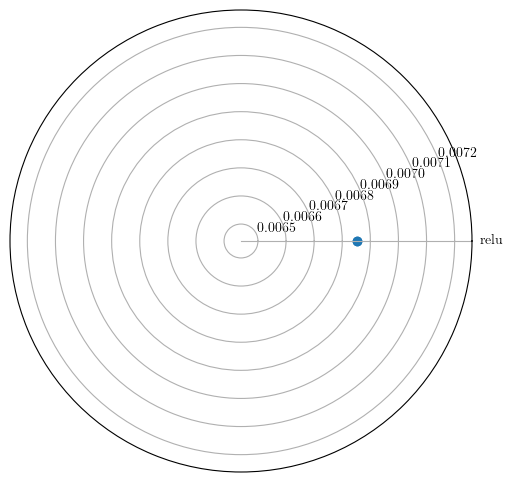

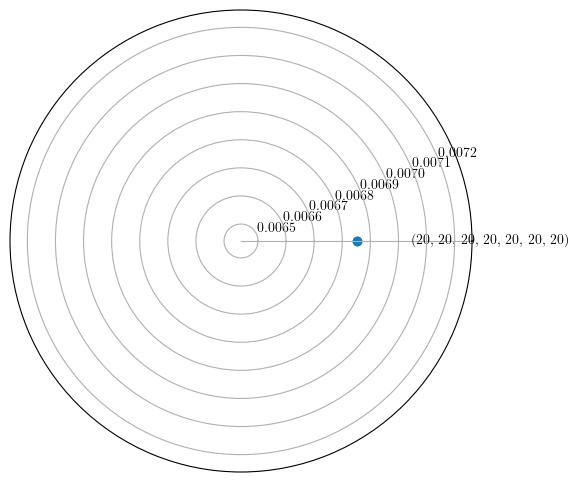

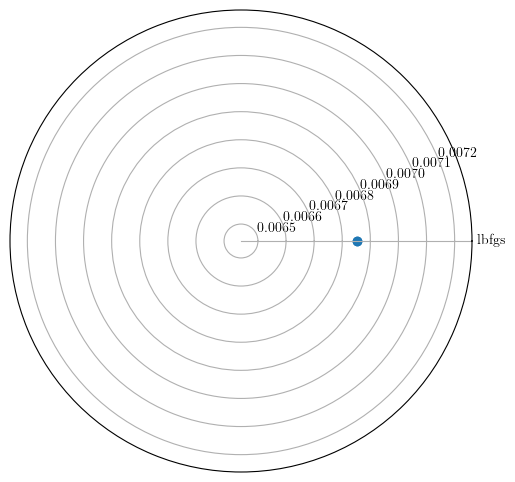

In [21]:
plot_cross_validation(nn_cv_result, 'mlp-hyperparams')

MLP
{'y_train': 204    0.678858
128    0.399096
315    0.479181
97     0.734070
318    0.476939
         ...   
167    0.650541
232    0.494174
348    0.840543
189    0.486737
151    0.776924
Name: Mn/Mp, Length: 352, dtype: float64, 'y_test': 398    0.865497
295    0.343300
200    0.295856
214    0.492424
330    0.818659
         ...   
304    0.767434
184    0.625606
269    0.402378
40     0.355125
33     0.268164
Name: Mn/Mp, Length: 87, dtype: float64, 'train_mse': 0.0001547050095132447, 'train_mae': 0.008628660035419011, 'train_r2': 0.997237627919961, 'test_mse': 0.007556339411533555, 'test_mae': 0.06463239726331366, 'test_r2': 0.8672110440773428, 'full_mse': 0.0016215437178862902, 'full_mae': 0.01972735055666465, 'full_r2': 0.9711438298208293, 'train_predictions': array([0.64746103, 0.42158787, 0.51686273, 0.72716638, 0.43557334,
       0.69015493, 0.78353895, 0.48510725, 0.69892365, 0.68738824,
       0.78238315, 0.30385614, 0.81063661, 0.83019628, 0.78719213,
       0.73981531,

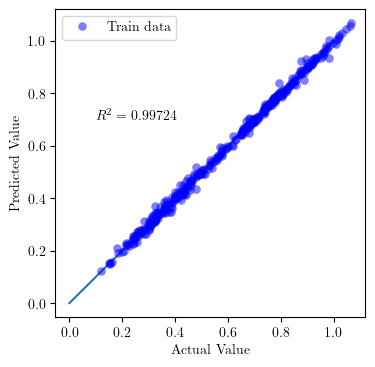

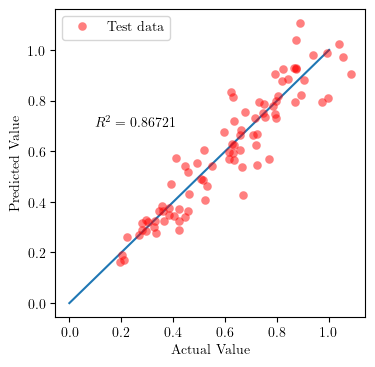

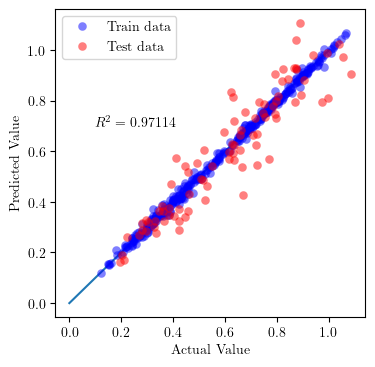

In [22]:
nn_metrics = evaluate_pipeline(nn_best, 0.3)
plot_accuracy(nn_metrics, 'MLP')

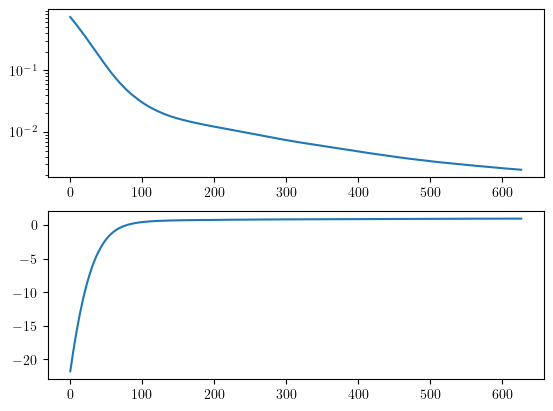

In [23]:
small_nn_params = {
    'mlp__hidden_layer_sizes' : [(x,) for x in range(1, 15)],
    'mlp__activation' : ['relu', 'tanh', 'logistic']
}

small_nn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(random_state=100, early_stopping=True, max_iter=2000))
])

small_nn_cv = GridSearchCV(small_nn_pipeline, small_nn_params, scoring='neg_mean_squared_error')
small_nn_cv.fit(X_train, y_train)

small_nn_best = small_nn_cv.best_estimator_
small_nn_cv_result = pd.DataFrame(small_nn_cv.cv_results_)

plt.subplot(2, 1, 1)
plt.semilogy(small_nn_best['mlp'].loss_curve_)
plt.subplot(2, 1, 2)
plt.plot(small_nn_best['mlp'].validation_scores_)
plt.savefig('small-nn/small-nn.png', dpi=640, bbox_inches='tight')

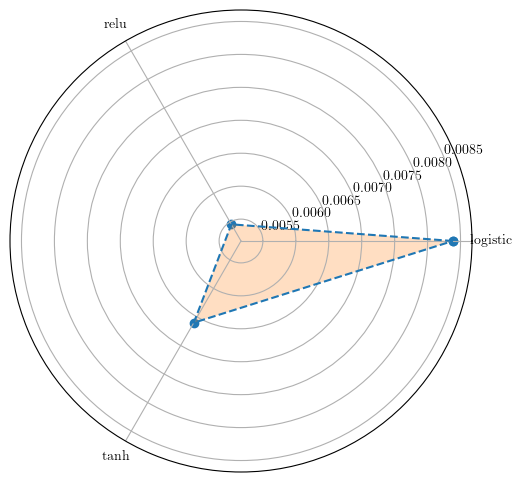

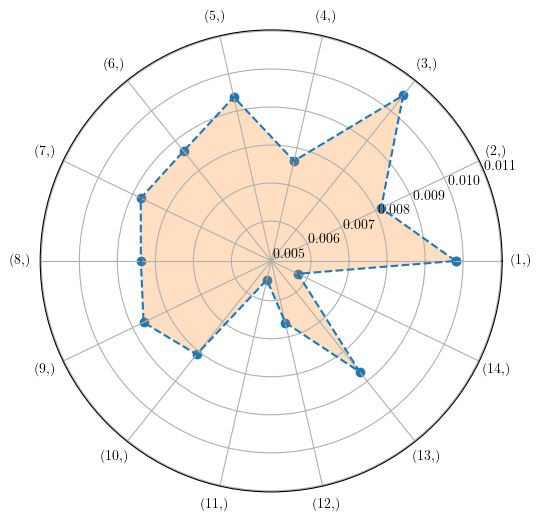

In [24]:
plot_cross_validation(small_nn_cv_result, 'small-nn-hyperparameters')

small-nn
{'y_train': 204    0.678858
128    0.399096
315    0.479181
97     0.734070
318    0.476939
         ...   
167    0.650541
232    0.494174
348    0.840543
189    0.486737
151    0.776924
Name: Mn/Mp, Length: 352, dtype: float64, 'y_test': 398    0.865497
295    0.343300
200    0.295856
214    0.492424
330    0.818659
         ...   
304    0.767434
184    0.625606
269    0.402378
40     0.355125
33     0.268164
Name: Mn/Mp, Length: 88, dtype: float64, 'train_mse': 0.004821797036765813, 'train_mae': 0.05375183925157105, 'train_r2': 0.9063914424935926, 'test_mse': 0.008621923357675282, 'test_mae': 0.06710359318622629, 'test_r2': 0.8194130922374674, 'full_mse': 0.005581822300947707, 'full_mae': 0.0564221900385021, 'full_r2': 0.8900371374964049, 'train_predictions': array([0.65536283, 0.47708927, 0.38930751, 0.83186545, 0.39067034,
       0.62673526, 0.70013339, 0.59631071, 0.65937811, 0.57961596,
       0.92708094, 0.2348894 , 0.83140316, 0.83442655, 0.69637066,
       0.7298700

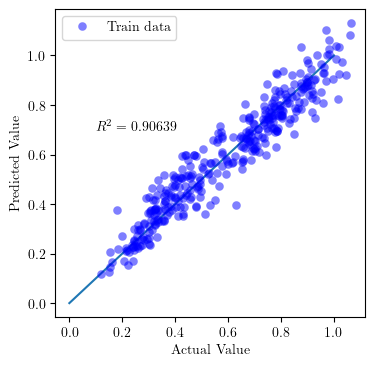

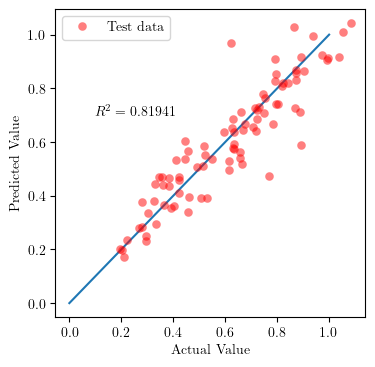

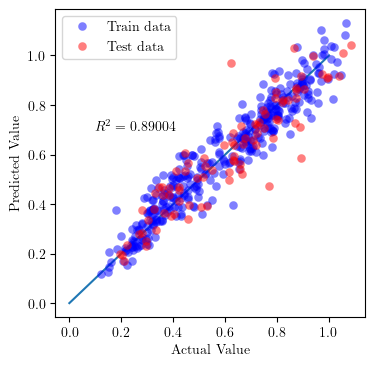

In [25]:
small_nn_metrics = evaluate_pipeline(small_nn_best, 100.0)
plot_accuracy(small_nn_metrics, 'small-nn')

In [26]:
og_data = pd.read_csv('original.csv')
og_data.head()

,Fy (ksi),Lb,bf,tf,tw,h0,ry,Mn(Modified),Mn(AISC code),Mn(FE model),Mp,b,Mcr
0,139.236,160,15.9,1.77,1.03,42.23,3.49,190298.5274,225562.320000,216638.377325,225562.32,15.9,399132.605082
1,139.236,190,15.9,1.77,1.03,42.23,3.49,171595.1703,219030.340139,197650.133747,225562.32,15.9,290051.468297
2,139.236,230,15.9,1.77,1.03,42.23,3.49,146147.7541,187966.043520,170240.744021,225562.32,15.9,205359.253150
3,139.236,260,15.9,1.77,1.03,42.23,3.49,128748.2021,155913.110942,139104.281134,225562.32,15.9,165618.043830
4,139.236,300,15.9,1.77,1.03,42.23,3.49,108993.2842,122477.537470,95629.312666,225562.32,15.9,129821.641396


In [27]:
og_data_ratio = pd.DataFrame()
og_data_ratio['Lb/ry'] = og_data['Lb'] / og_data['ry']
og_data_ratio['h/tw'] = og_data['h0'] / og_data['tw']
og_data_ratio['B/2t'] = og_data['b'] / 2 * og_data['tf']
og_data_ratio['h/B'] = og_data['h0'] / og_data['b']
og_data_ratio['tf/tw'] = og_data['tf'] / og_data['tw']
og_data_ratio['E/Fy'] = 29e3 / og_data['Fy (ksi)']
og_data_ratio['Mp/Mcr'] = og_data['Mp'] / og_data['Mcr']
og_data_ratio['Mn/Mp (AISC)'] = og_data['Mn(AISC code)'] / og_data['Mp']
og_data_ratio['Mn/Mp (MOD)'] = og_data['Mn(Modified)'] / og_data['Mp']

In [28]:
og_data_ratio.head()

,Lb/ry,h/tw,B/2t,h/B,tf/tw,E/Fy,Mp/Mcr,Mn/Mp (AISC),Mn/Mp (MOD)
0,45.845272,41.0,14.0715,2.655975,1.718447,208.279468,0.565131,1.000000,0.843663
1,54.441261,41.0,14.0715,2.655975,1.718447,208.279468,0.777663,0.971041,0.760744
2,65.902579,41.0,14.0715,2.655975,1.718447,208.279468,1.098379,0.833322,0.647926
3,74.498567,41.0,14.0715,2.655975,1.718447,208.279468,1.361943,0.691220,0.570788
4,85.959885,41.0,14.0715,2.655975,1.718447,208.279468,1.737479,0.542988,0.483207


In [29]:
df.head()

,Lb/ry,h/tw,B/2t,h/B,tf/tw,E/Fy,Mp/Mcr,Mn/Mp
0,45.845272,41.0,41.0,41.0,1.718447,208.279468,0.565131,0.960437
1,54.441261,41.0,41.0,41.0,1.718447,208.279468,0.777663,0.876255
2,65.902579,41.0,41.0,41.0,1.718447,208.279468,1.098379,0.754739
3,74.498567,41.0,41.0,41.0,1.718447,208.279468,1.361943,0.616700
4,85.959885,41.0,41.0,41.0,1.718447,208.279468,1.737479,0.423960


In [30]:
mse_code = mean_squared_error(og_data_ratio['Mn/Mp (AISC)'], og_data_ratio['Mn/Mp (MOD)'])
r2_code = r2_score(og_data_ratio['Mn/Mp (AISC)'], og_data_ratio['Mn/Mp (MOD)'])
print(mse_code)
print(r2_code)

0.027484151024631094
0.6181763301765262


In [31]:
mae_code = mean_absolute_error(og_data_ratio['Mn/Mp (AISC)'], og_data_ratio['Mn/Mp (MOD)'])
print(mae_code)

0.12830643132026942
